# Clustering des journées — OQAI CNL1

Ce notebook explore différentes approches de clustering sur les journées CO₂.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

sns.set_theme(style='whitegrid', palette='colorblind', font_scale=1.05)
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (14, 4)})
pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.max_columns', 30)

CLEAN = Path("../data/cln1/Clean")

log     = pd.read_parquet(CLEAN / "Referentiels/logements.parquet")
sem     = pd.read_parquet(CLEAN / "Comportement/semainier.parquet")
jour    = pd.read_parquet(CLEAN / "Comportement/journalier.parquet")
co2     = pd.read_parquet(CLEAN / "Mesures/co2.parquet")
co      = pd.read_parquet(CLEAN / "Mesures/co.parquet")
confort = pd.read_parquet(CLEAN / "Mesures/confort.parquet")
q_ind   = pd.read_parquet(CLEAN / "Questionnaires/q_individu.parquet")
q_men   = pd.read_parquet(CLEAN / "Questionnaires/q_menage.parquet")
q_pie   = pd.read_parquet(CLEAN / "Questionnaires/q_piece.parquet")
q_te    = pd.read_parquet(CLEAN / "Questionnaires/q_te.parquet")
beta    = pd.read_parquet(CLEAN / "Questionnaires/infos_beta.parquet")

ZONE_ORDER   = ['H1', 'H2', 'H3']
SAISON_ORDER = ['Hiver', 'Printemps', 'Été', 'Automne']
ZONE_COLORS  = {'H1':'#4C72B0', 'H2':'#55A868', 'H3':'#C44E52'}
SAIS_COLORS  = {'Hiver':'#4C72B0','Printemps':'#55A868','Été':'#C44E52','Automne':'#8172B2'}

# IDN_PIECE (code brut) → room_id (groupe 1-13) → label
ROOM_ID = {
    11:1, 12:1, 13:1, 14:1, 15:1, 16:1,
    20:2, 21:2, 22:2, 23:2, 24:2, 25:2,
    55:3,
    17:4, 18:4, 19:4,
    29:5, 30:5, 31:5,
    26:6, 27:6,
    32:7, 33:7, 34:7,
    35:8, 36:8, 37:8,
    38:9,
    41:10, 42:10, 43:10, 44:10, 45:10, 46:10,
    50:11, 51:11,
    90:12,
    60:13, 61:13, 62:13, 64:13, 65:13,
    74:13, 75:13, 76:13, 77:13, 78:13, 79:13,
    80:13, 81:13, 82:13, 83:13, 84:13, 85:13,
    86:13, 87:13, 88:13, 99:13,
}
ROOM_LABEL = {
    1:'Chambre', 2:'Séjour/Salon', 3:'Studio', 4:'Cuisine',
    5:'Salle de bains', 6:'Buanderie', 7:'WC', 8:'Bureau',
    9:'Chaufferie', 10:'Cave/Grenier', 11:'Garage',
    12:'Extérieur', 13:'Autre pièce',
}

# Enrichissement : ajout zone_climatique + saison à chaque dataset de mesures
SEG = log[['CODELIEU','zone_climatique','saison']].copy()

co2_e     = co2.merge(SEG, on='CODELIEU', how='left')
co_e      = co.merge(SEG, on='CODELIEU', how='left')
confort_e = confort.merge(SEG, on='CODELIEU', how='left')
jour_e    = jour.merge(SEG, on='CODELIEU', how='left')
q_ind_e   = q_ind.merge(SEG, on='CODELIEU', how='left')
q_men_e   = q_men.merge(SEG, on='CODELIEU', how='left')

# Ajout room_label sur les séries physiques (IDN_PIECE → room_id → label)
co2_e['room_label']     = co2_e['IDN_PIECE'].map(ROOM_ID).map(ROOM_LABEL)
co_e['room_label']      = co_e['IDN_PIECE'].map(ROOM_ID).map(ROOM_LABEL)
confort_e['room_label'] = confort_e['IDN_PIECE'].map(ROOM_ID).map(ROOM_LABEL)

print("Données chargées et enrichies ✓")
for name, df in [('co2_e',co2_e),('confort_e',confort_e),('co_e',co_e),
                 ('jour_e',jour_e),('q_ind_e',q_ind_e)]:
    print(f"  {name:<12} {len(df):>10,} lignes")
    
co2_e['heure'] = co2_e['DATE_HEURE'].dt.hour


Données chargées et enrichies ✓
  co2_e           503,822 lignes
  confort_e       508,231 lignes
  co_e          2,875,522 lignes
  jour_e          197,640 lignes
  q_ind_e           1,612 lignes


In [2]:
def _plot_pca_clusters(ax, x2d, lbls, n_clusters, title, ev_ratio):
    ax.scatter(x2d[:, 0], x2d[:, 1], c=lbls, cmap='tab10', s=40, alpha=0.7)
    for c in range(n_clusters):
        mask = lbls == c
        if mask.sum() == 0: continue
        cx, cy = x2d[mask, 0].mean(), x2d[mask, 1].mean()
        ax.annotate(f'C{c}', (cx, cy), fontsize=9, fontweight='bold', ha='center',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, edgecolor='grey'))
    ax.set_xlabel(f'PC1 ({ev_ratio[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({ev_ratio[1]*100:.1f}%)')
    ax.set_title(title, fontweight='bold'); ax.grid(True, alpha=0.2)


def kmeans_ksel(X, ks, rng_seed, suptitle, mark_k=None, n_init=30, n_stability=8):
    from sklearn.metrics import silhouette_score, adjusted_rand_score
    rng = np.random.RandomState(rng_seed)
    inerties, sils, stabs = [], [], []
    for k in ks:
        km  = KMeans(n_clusters=k, random_state=42, n_init=n_init)
        lab = km.fit_predict(X)
        inerties.append(km.inertia_)
        sils.append(silhouette_score(X, lab, sample_size=2000, random_state=0))
        aris = []
        for _ in range(n_stability):
            idx  = rng.choice(len(X), int(0.8 * len(X)), replace=False)
            lab2 = KMeans(n_clusters=k, random_state=rng.randint(10**6), n_init=n_init).fit_predict(X[idx])
            aris.append(adjusted_rand_score(lab[idx], lab2))
        stabs.append(np.mean(aris))
    fig, axes = plt.subplots(1, 3, figsize=(17, 4))
    axes[0].plot(ks, inerties, 'o-', color='#C44E52', lw=2)
    axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertie'); axes[0].set_title('Coude', fontweight='bold')
    axes[1].plot(ks, sils, 'bo-', lw=2)
    axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette'); axes[1].set_title('Séparation', fontweight='bold')
    axes[2].plot(ks, stabs, 'go-', lw=2)
    axes[2].set_xlabel('k'); axes[2].set_ylabel('ARI (80%)'); axes[2].set_title('Stabilité', fontweight='bold')
    for ax in axes:
        if mark_k is not None:
            ax.axvline(mark_k, color='grey', ls='--', lw=1, alpha=0.6)
        ax.grid(True, alpha=0.3)
    plt.suptitle(suptitle, fontweight='bold', fontsize=12)
    plt.tight_layout(); plt.show()
    print(f'Silhouette max : k={ks[sils.index(max(sils))]}')
    return inerties, sils, stabs


def plot_cluster_profiles(prof_df, daytype_col, t_axis, ylabel, title):
    t_axis = list(t_axis)
    n_pts  = len(t_axis)
    clusters = sorted(prof_df[daytype_col].unique())
    colors   = sns.color_palette('husl', len(clusters))
    fig, ax = plt.subplots(figsize=(13, 6))
    for color, c in zip(colors, clusters):
        sub = prof_df[prof_df[daytype_col] == c]
        m   = sub[list(range(n_pts))].mean()
        s   = sub[list(range(n_pts))].std()
        ax.plot(t_axis, m, lw=1.8, color=color, label=f'C{c}  (n={len(sub)})')
        ax.fill_between(t_axis, m - s, m + s, alpha=0.06, color=color)
    ax.axhline(0, color='grey', lw=0.8, ls='--', alpha=0.6)
    ax.set_xticks(range(0, 24, 3)); ax.set_xticklabels([f'{h}h' for h in range(0, 24, 3)])
    ax.set_xlabel('Heure'); ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=10); ax.grid(True, alpha=0.25)
    plt.tight_layout(); plt.show()
    print(prof_df[daytype_col].value_counts().sort_index()
          .rename('n journées').rename_axis('cluster').to_frame().T)


def plot_elbow(X, k_range=range(2, 21), n_init=10, title='', mark_k=None):
    inerties = [KMeans(n_clusters=k, random_state=42, n_init=n_init).fit(X).inertia_
                for k in k_range]
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(list(k_range), inerties, 'o-', color='#C44E52', lw=2)
    if mark_k is not None:
        ax.axvline(mark_k, color='grey', ls='--', lw=1.5, label=f'k={mark_k} choisi')
        ax.legend()
    ax.set_xlabel('k'); ax.set_ylabel('Inertie')
    ax.set_title(f'Coude inertie — {title}', fontweight='bold')
    ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()


## Profil des occupants — actifs vs autres

Distribution des occupants selon leur statut professionnel déclaré (`INDT`), puis
des **logements** selon qu'ils comptent au moins un actif occupé ou aucun
(population restreinte aux logements équipés d'un capteur CO₂, cohérente avec
le reste du notebook).

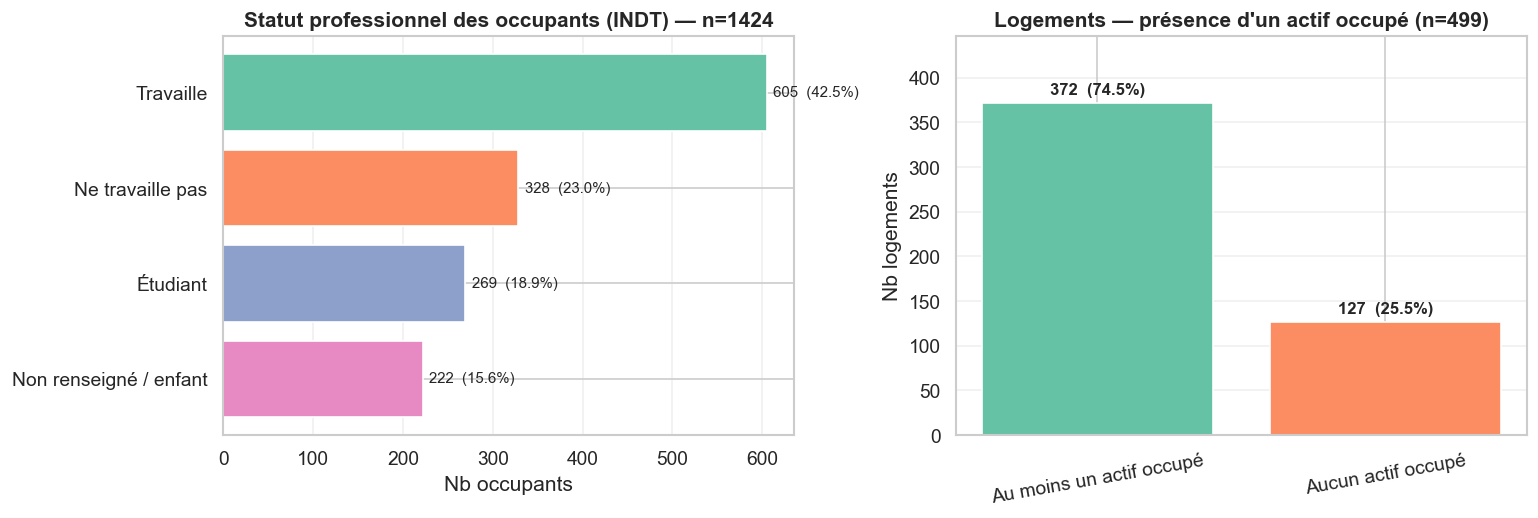

statut_pro
Au moins un actif occupé    372
Aucun actif occupé          127


In [3]:
# INDT : 1=Travaille (profession/stage rémunéré), 2=Étudiant, 3=Ne travaille pas
INDT_LABELS = {'1': 'Travaille', '2': 'Étudiant', '3': 'Ne travaille pas'}
q_ind_e['statut_pro'] = q_ind_e['INDT'].map(INDT_LABELS).fillna('Non renseigné / enfant')

logs_co2 = set(co2_e['CODELIEU'].unique())
occ = q_ind_e[q_ind_e['CODELIEU'].isin(logs_co2)]

# Logement = "au moins un actif occupé" si un des occupants a INDT=1
has_actif = occ.groupby('CODELIEU')['statut_pro'].apply(lambda s: (s == 'Travaille').any())
log_class = has_actif.map({True: 'Au moins un actif occupé', False: 'Aucun actif occupé'})

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# 1. Distribution des occupants par statut
ax = axes[0]
counts_occ = occ['statut_pro'].value_counts()
colors = sns.color_palette('Set2', len(counts_occ))
bars = ax.barh(counts_occ.index, counts_occ.values, color=colors, edgecolor='white')
ax.bar_label(bars,
             labels=[f'{v}  ({100*v/counts_occ.sum():.1f}%)' for v in counts_occ.values],
             padding=4, fontsize=9)
ax.set_xlabel('Nb occupants')
ax.set_title(f'Statut professionnel des occupants (INDT) — n={counts_occ.sum()}',
             fontweight='bold')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)

# 2. Distribution des logements : au moins un actif vs aucun
ax = axes[1]
counts_log = log_class.value_counts()
colors2 = sns.color_palette('Set2', len(counts_log))
bars = ax.bar(counts_log.index, counts_log.values, color=colors2, edgecolor='white')
ax.bar_label(bars,
             labels=[f'{v}  ({100*v/counts_log.sum():.1f}%)' for v in counts_log.values],
             padding=3, fontsize=10, fontweight='bold')
ax.set_ylabel('Nb logements')
ax.set_title(f'Logements — présence d\'un actif occupé (n={counts_log.sum()})',
             fontweight='bold')
ax.set_ylim(0, counts_log.max() * 1.2)
ax.tick_params(axis='x', labelrotation=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout(); plt.show()

print(counts_log.to_string())


## 6 Clustering des journées (day-types) — validé par le semainier

Changement de granularité : au lieu de clusteriser les **logements** (~500 individus, structure faible — silhouette ≤ 0.18),
on clusterise les **journées** (~3 000 individus). Chaque journée = profil CO₂ 24h, **z-normé par logement**
(on compare des formes, pas des niveaux : 800 ppm dans un studio ≠ 800 ppm dans une maison).

Points clés établis sur les données :
- 95% des capteurs CO₂ sont en **chambre** → le signal mesure surtout l'occupation nocturne (sommeil) ;
- le **semainier** (présence déclarée par occupant, pas de 10 min, `IDN_PIECE=90` = extérieur) sert de **vérité terrain** ;
- chaque logement n'a que ~2 jours de week-end → la signature logement est construite sur les **jours de semaine** (≥ 3 jours).

In [4]:
co2_e['DATE'] = co2_e['DATE_HEURE'].dt.normalize()

pts_jour       = co2_e.groupby(['CODELIEU', 'DATE']).size()
jours_complets = pts_jour[pts_jour >= 138].index

co2_j     = co2_e.set_index(['CODELIEU', 'DATE']).loc[jours_complets].reset_index()
stats_log = co2_j.groupby('CODELIEU')['VALEUR'].agg(['mean', 'std'])
co2_j     = co2_j.merge(stats_log, on='CODELIEU')
co2_j['z']    = (co2_j['VALEUR'] - co2_j['mean']) / co2_j['std']
co2_j['slot'] = co2_j['DATE_HEURE'].dt.hour * 6 + co2_j['DATE_HEURE'].dt.minute // 10

prof_jour = co2_j.groupby(['CODELIEU', 'DATE', 'heure'])['z'].mean().unstack('heure').dropna()
X_jour    = prof_jour.values

print(f'Jours complets   : {len(jours_complets):,} / {len(pts_jour):,}')
print(f'Profils retenus  : {len(prof_jour):,} journées  ({prof_jour.index.get_level_values(0).nunique()} logements)')
print(f'Shape            : {X_jour.shape}  (journées x heures)')
display(prof_jour.head(3).round(2))


Jours complets   : 3,012 / 4,010
Profils retenus  : 3,002 journées  (499 logements)
Shape            : (3002, 24)  (journées x heures)


heure                  0     1     2     3     4    5     6     7     8   \
CODELIEU DATE                                                              
01-M001  2004-05-13  0.13  1.05 -0.16  0.16 -0.06 0.03 -0.09 -0.62 -0.59   
         2004-05-14 -0.36 -0.00 -0.16 -0.02 -0.12 0.04  0.26 -0.93 -1.31   
         2004-05-15  0.25  0.38  0.43  0.23  0.28 0.00 -0.43 -0.64 -0.70   

heure                  9     10   11    12   13    14    15    16    17    18  \
CODELIEU DATE                                                                   
01-M001  2004-05-13 -0.50  0.89 1.18  1.37 2.35  2.10  0.72 -0.84 -0.85 -0.14   
         2004-05-14 -1.25 -0.99 1.70  1.43 1.89  1.20  1.38 -0.41 -1.17 -1.55   
         2004-05-15 -0.09  1.48 1.54 -0.13 0.25 -0.51 -1.18 -0.34 -0.56 -1.00   

heure                  19    20    21    22    23  
CODELIEU DATE                                      
01-M001  2004-05-13 -0.12 -0.05  0.05 -0.37 -0.38  
         2004-05-14 -1.13 -0.74 -1.33 -0.77  0.62  
         2004-05-15 -0.83 -0.61  0.67  1.12  0.78

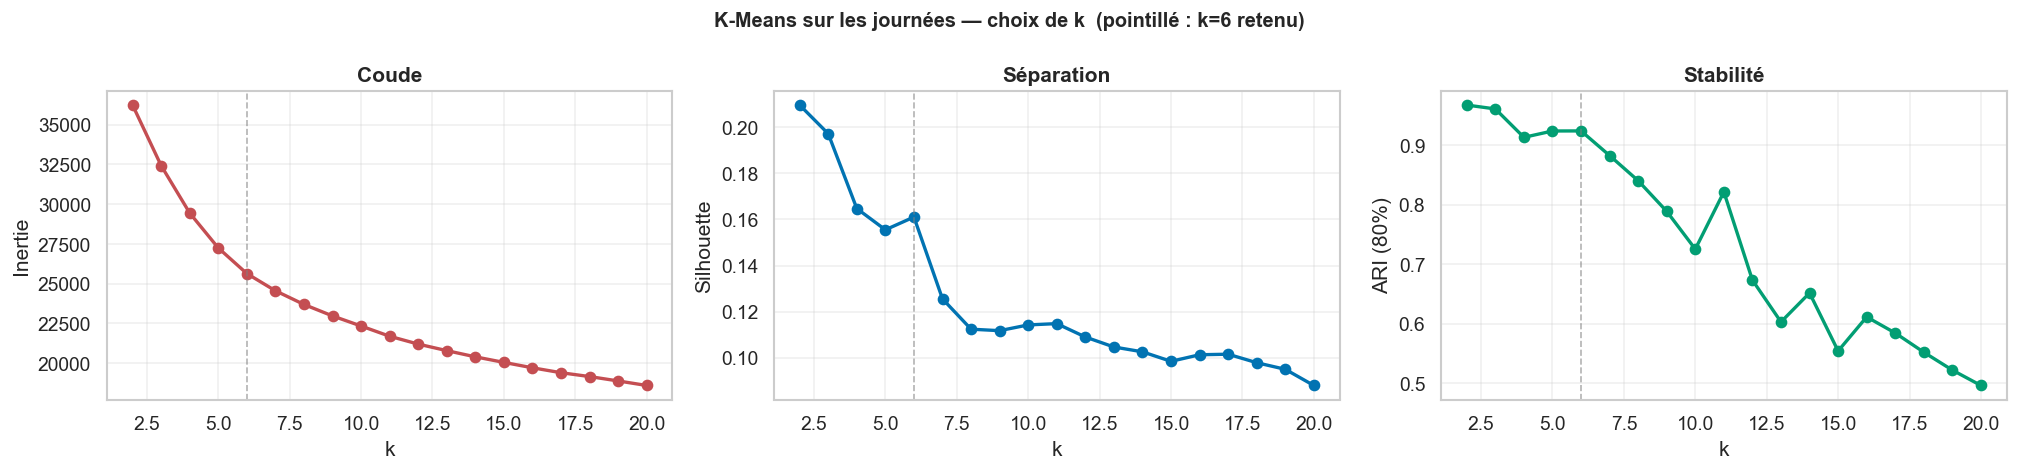

Silhouette max : k=2


In [5]:
kmeans_ksel(X_jour, list(range(2, 21)), rng_seed=0,
            suptitle='K-Means sur les journées — choix de k  (pointillé : k=6 retenu)',
            mark_k=6);


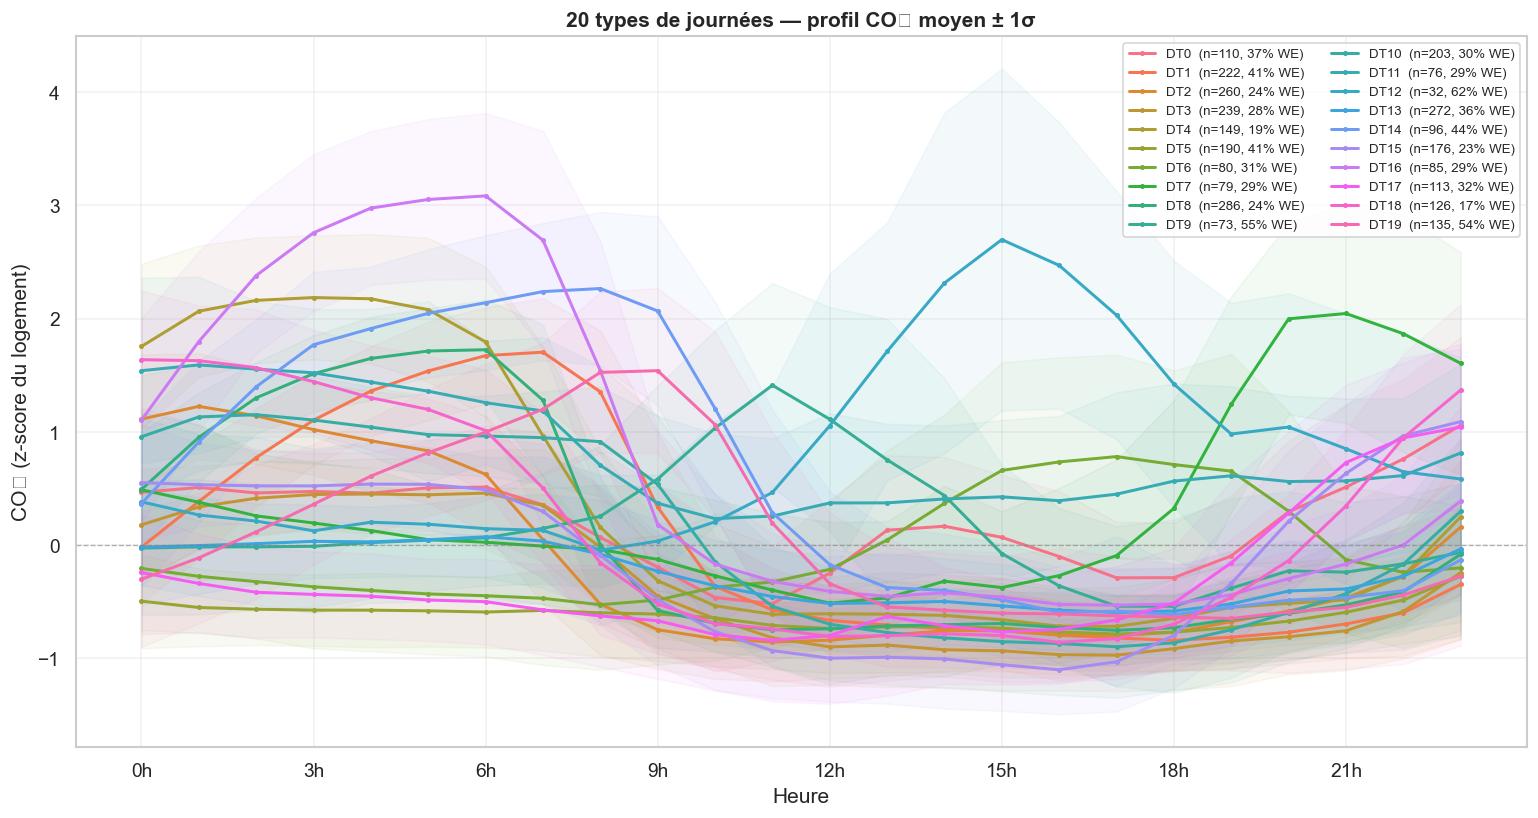

In [6]:
K_JOUR    = 20
km_jour   = KMeans(n_clusters=K_JOUR, random_state=42, n_init=30)
dt_labels = km_jour.fit_predict(X_jour)

prof_dt = prof_jour.copy()
prof_dt['daytype'] = dt_labels
prof_dt['we']      = prof_dt.index.get_level_values('DATE').dayofweek >= 5

colors = sns.color_palette('husl', K_JOUR)
fig, ax = plt.subplots(figsize=(13, 7))
for c, color in zip(range(K_JOUR), colors):
    sub  = prof_dt[prof_dt['daytype'] == c]
    m    = sub[list(range(24))].mean()
    s    = sub[list(range(24))].std()
    ax.plot(range(24), m, lw=1.8, marker='o', ms=2, color=color,
            label=f'DT{c}  (n={len(sub)}, {100*sub["we"].mean():.0f}% WE)')
    ax.fill_between(range(24), m - s, m + s, alpha=0.06, color=color)

ax.axhline(0, color='grey', lw=0.8, ls='--', alpha=0.6)
ax.set_xticks(range(0, 24, 3)); ax.set_xticklabels([f"{h}h" for h in range(0, 24, 3)])
ax.set_xlabel('Heure'); ax.set_ylabel('CO₂ (z-score du logement)')
ax.set_title(f'{K_JOUR} types de journées — profil CO₂ moyen ± 1σ',
             fontweight='bold')
ax.legend(fontsize=8, ncol=2); ax.grid(True, alpha=0.25)
plt.tight_layout(); plt.show()


NameError: name 'DT_NOMS' is not defined

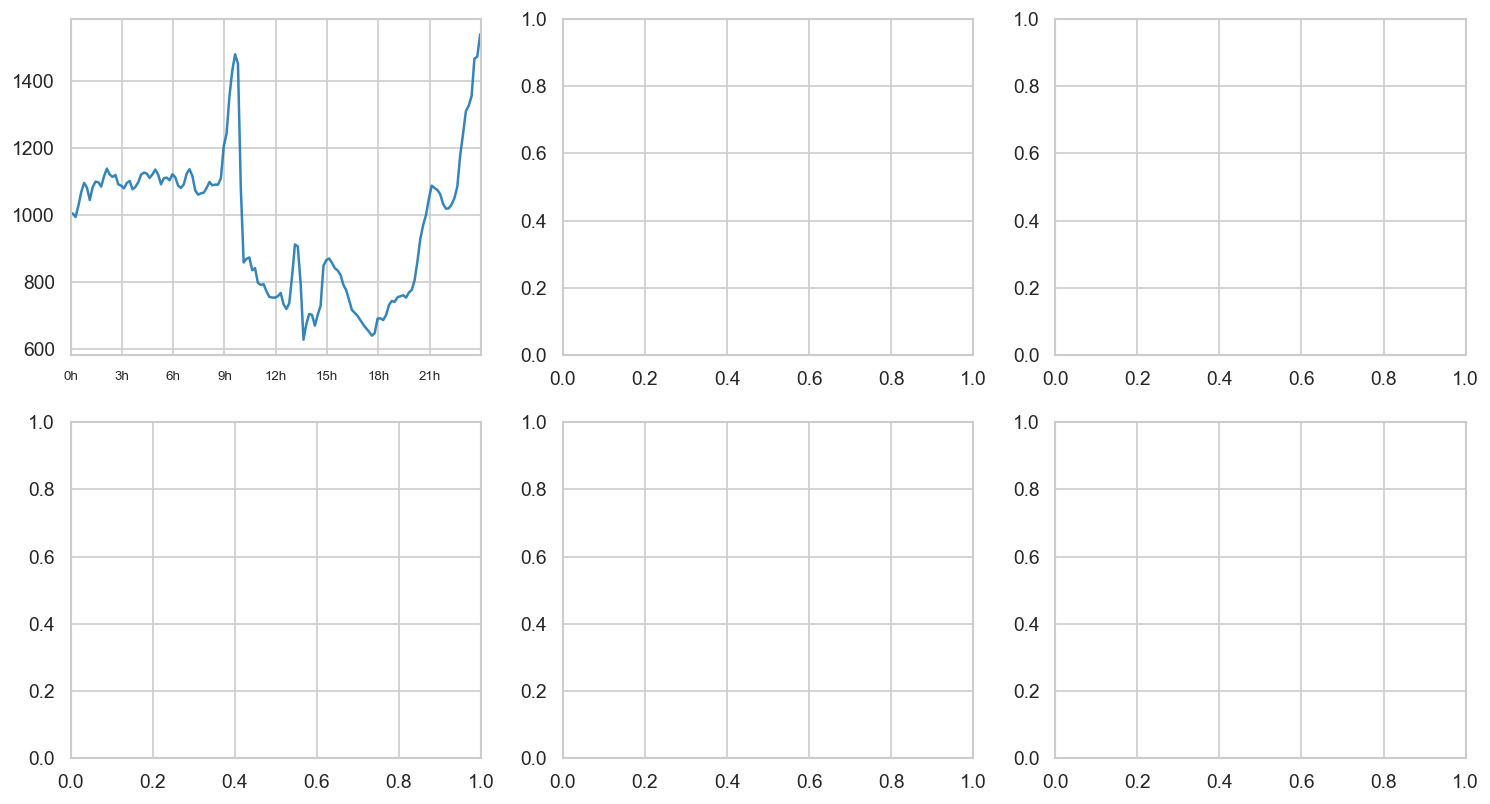

In [7]:
# Donnees brutes CO2 a 10 min — une journee arbitraire par day-type
# Figure 1 : ppm brut  |  Figure 2 : z-normalise par logement

rng = np.random.default_rng(42)

# Tirage des journees (une par day-type, reproductible)
exemples = {}
for c in range(K_JOUR):
    sub = prof_dt[prof_dt['daytype'] == c]
    cod, dat = sub.index[rng.integers(len(sub))]
    mask = (co2_e['CODELIEU'] == cod) & (co2_e['DATE'] == dat)
    raw  = co2_e[mask].sort_values('DATE_HEURE')[['DATE_HEURE', 'VALEUR']].dropna().copy()
    raw['t_min'] = (raw['DATE_HEURE'] - raw['DATE_HEURE'].dt.normalize()).dt.total_seconds() / 60
    mu  = co2_e[co2_e['CODELIEU'] == cod]['VALEUR'].mean()
    sig = co2_e[co2_e['CODELIEU'] == cod]['VALEUR'].std()
    raw['z'] = (raw['VALEUR'] - mu) / sig
    exemples[c] = (cod, dat, raw)

for mode, ylabel, col in [('ppm', 'CO₂ (ppm)', 'VALEUR'), ('z', 'CO₂ (z-score logement)', 'z')]:
    fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=(mode == 'z'))
    axes = axes.flatten()
    for c in range(K_JOUR):
        cod, dat, raw = exemples[c]
        color = plt.cm.tab10(c / 9)
        ax    = axes[c]
        ax.plot(raw['t_min'], raw[col], color=color, lw=1.5, alpha=0.9)
        if mode == 'z':
            ax.axhline(0, color='grey', lw=0.6, ls='--', alpha=0.4)
        ax.set_xticks([h * 60 for h in range(0, 24, 3)])
        ax.set_xticklabels([f'{h}h' for h in range(0, 24, 3)], fontsize=8)
        ax.set_xlim(0, 1440)
        ax.set_title(f'DT{c} — {DT_NOMS[c]}', fontweight='bold', fontsize=10)
        ax.set_xlabel('Heure')
        ax.set_ylabel(ylabel)
        ax.grid(True, alpha=0.2)
        ax.text(0.02, 0.97, f'{cod}  |  {pd.Timestamp(dat).date()}  |  {len(raw)} pts',
                transform=ax.transAxes, fontsize=7, va='top', color='#333')
    titre = ('Donnees brutes CO₂ a 10 min — ppm absolu'
             if mode == 'ppm' else
             'Donnees brutes CO₂ a 10 min — z-normalise par logement')
    plt.suptitle(titre, fontweight='bold', fontsize=12)
    plt.tight_layout(); plt.show()

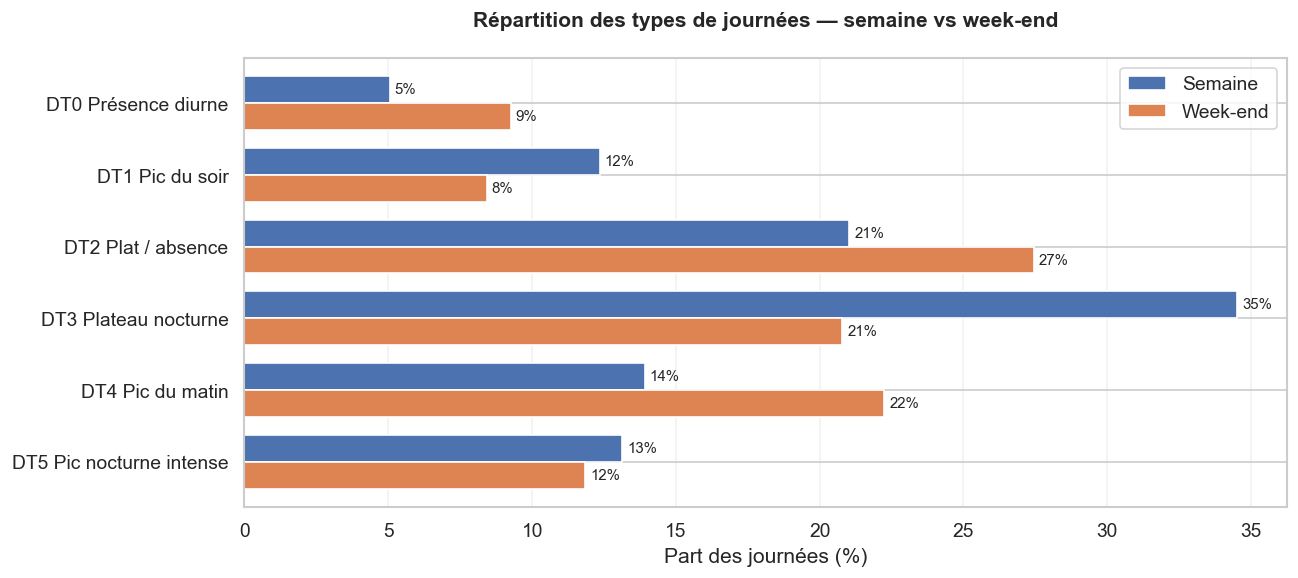

In [ ]:

dist = (prof_dt.groupby('we')['daytype'].value_counts(normalize=True)
        .unstack('daytype') * 100)
dist.index = ['Semaine', 'Week-end']
dist.columns = [f'DT{c} {DT_NOMS[c]}' for c in dist.columns]

ax = dist.T.plot(kind='barh', figsize=(11, 5), width=0.75,
                 color=['#4C72B0', '#DD8452'])
for cont in ax.containers:
    ax.bar_label(cont, fmt='%.0f%%', fontsize=9, padding=3)
ax.set_xlabel('Part des journées (%)')
ax.set_title('Répartition des types de journées — semaine vs week-end\n',
             fontweight='bold')
ax.grid(True, alpha=0.25, axis='x')
ax.invert_yaxis()
plt.tight_layout(); plt.show()

Occupants exclus (TAUX_REMPLI_BET=0) : 0
Journees avec CO2 + semainier : 2,715


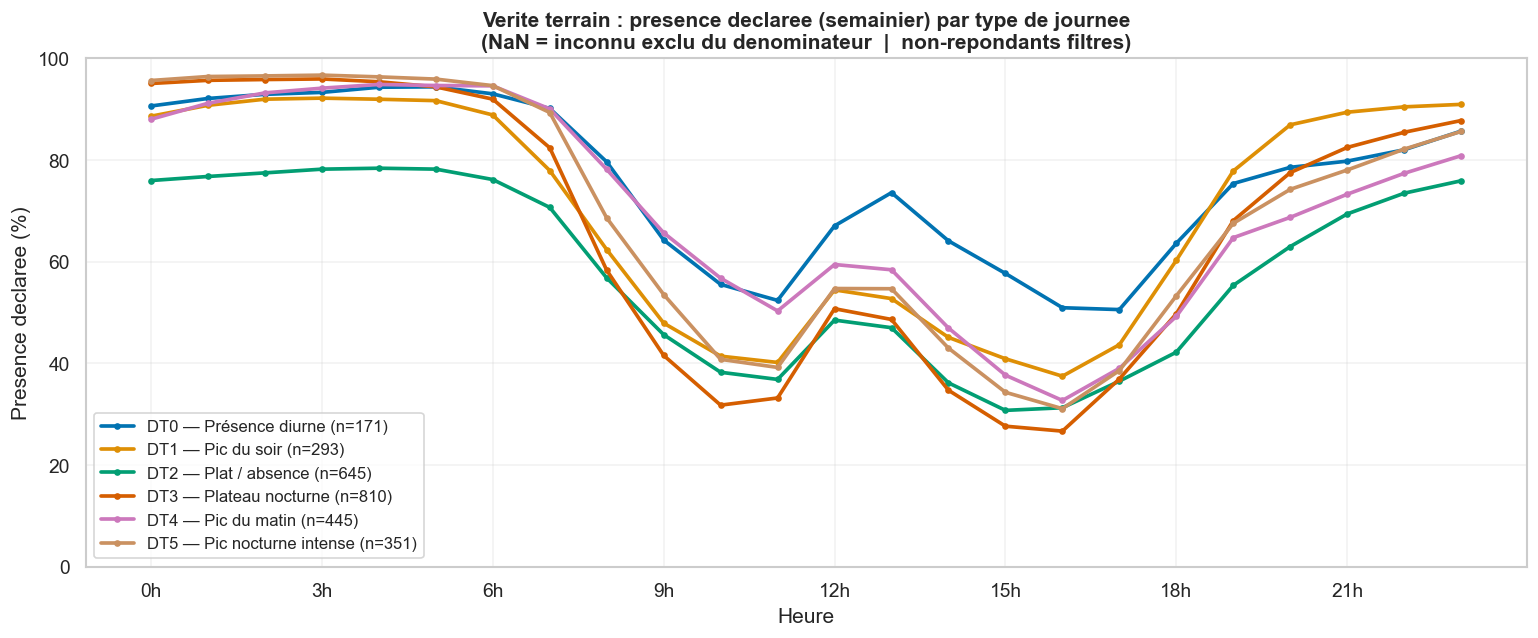

In [ ]:
# Validation par le semainier : presence declaree du menage, par type de journee

# Amelioration 1 : exclure les occupants qui n'ont pas rempli leur semainier (TAUX_REMPLI_BET=0)
occupants_valides = beta[beta['TAUX_REMPLI_BET'] > 0][['CODELIEU', 'NUM_OCCUPANT']]
sem_v = sem.merge(occupants_valides, on=['CODELIEU', 'NUM_OCCUPANT'], how='inner')
n_exclus = sem['NUM_OCCUPANT'].nunique() - sem_v['NUM_OCCUPANT'].nunique()
print(f'Occupants exclus (TAUX_REMPLI_BET=0) : {n_exclus}')

# Amelioration 2 : NaN IDN_PIECE = inconnu (exclu du denominateur), pas absent
sem_v = sem_v.copy()
sem_v['heure']   = (sem_v['CODE_HEURE'].str[2:].astype(int) - 1001) // 6
sem_v['present'] = sem_v['IDN_PIECE'].map(lambda x: np.nan if pd.isna(x) else float(x != 90))

# taux de presence par logement x date x heure (NaN ignores par .mean())
pres_jour = sem_v.groupby(['CODELIEU', 'DATE', 'heure'])['present'].mean().unstack('heure')

common = prof_dt.index.intersection(pres_jour.index)
pres_c = pres_jour.loc[common]
lab_c  = prof_dt.loc[common, 'daytype']
print(f'Journees avec CO2 + semainier : {len(common):,}')

fig, ax = plt.subplots(figsize=(13, 5.5))
for c in range(K_JOUR):
    m = pres_c[lab_c == c].mean() * 100
    ax.plot(range(24), m, lw=2.2, marker='o', ms=3,
            label=f'DT{c} — {DT_NOMS[c]} (n={(lab_c == c).sum()})')

ax.set_xticks(range(0, 24, 3)); ax.set_xticklabels([f'{h}h' for h in range(0, 24, 3)])
ax.set_xlabel('Heure'); ax.set_ylabel('Presence declaree (%)')
ax.set_ylim(0, 100)
ax.set_title('Verite terrain : presence declaree (semainier) par type de journee\n'
             '(NaN = inconnu exclu du denominateur  |  non-repondants filtres)',
             fontweight='bold')
ax.legend(fontsize=10); ax.grid(True, alpha=0.25)
plt.tight_layout(); plt.show()


## 6b. Clustering journées : dérivée dCO₂/dt


Journées avec 144 slots complets : 2,978


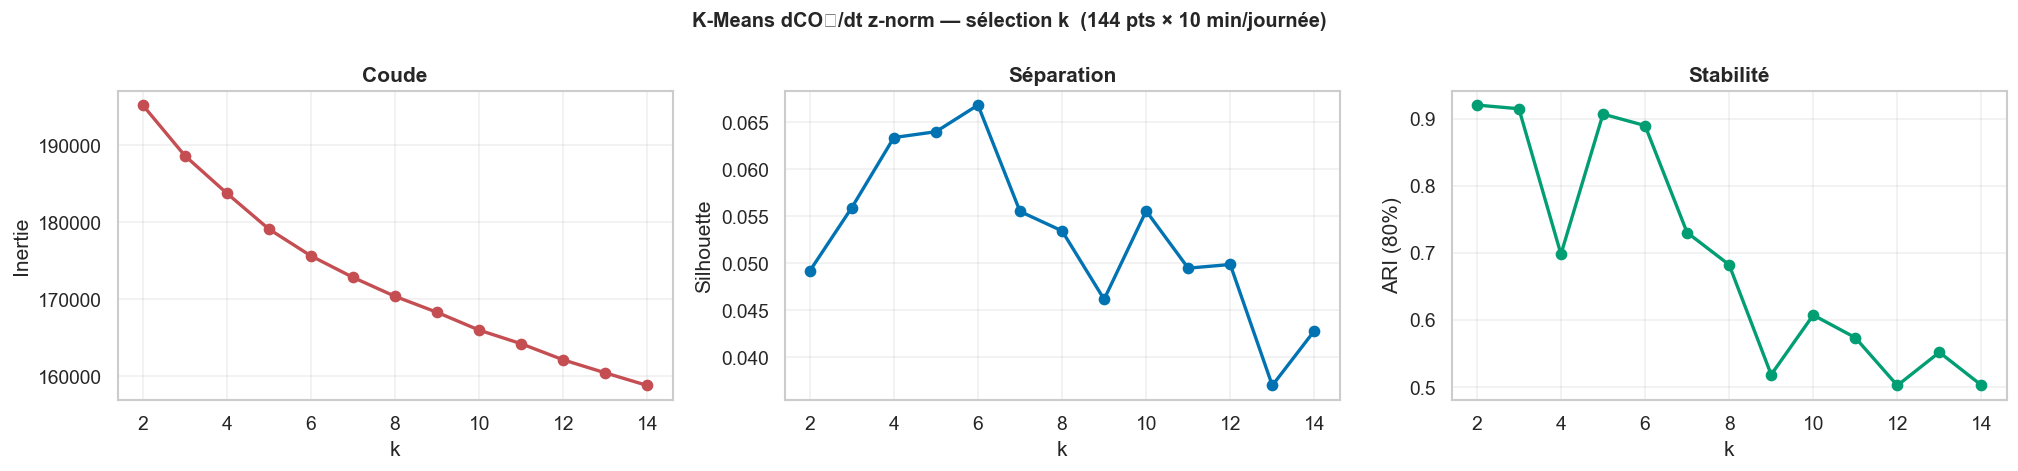

Silhouette max : k=6


In [ ]:
from scipy.signal import savgol_filter

WINDOW_10 = 5;  POLY_10 = 2;  DELTA_10 = 1 / 6

slot_piv = (co2_j.groupby(['CODELIEU', 'DATE', 'slot'])['z']
             .mean().unstack('slot').sort_index(axis=1).dropna())
print(f'Journées avec 144 slots complets : {len(slot_piv):,}')

deriv_s = np.apply_along_axis(
    lambda x: savgol_filter(x, WINDOW_10, POLY_10, deriv=1, delta=DELTA_10),
    1, slot_piv.values)

deriv_prof = pd.DataFrame(deriv_s, index=slot_piv.index, columns=range(144))
X_deriv    = deriv_prof.values

kmeans_ksel(X_deriv, list(range(2, 15)), rng_seed=2,
            suptitle='K-Means dCO\u2082/dt z-norm \u2014 s\u00e9lection k  (144 pts \u00d7 10 min/journ\u00e9e)');


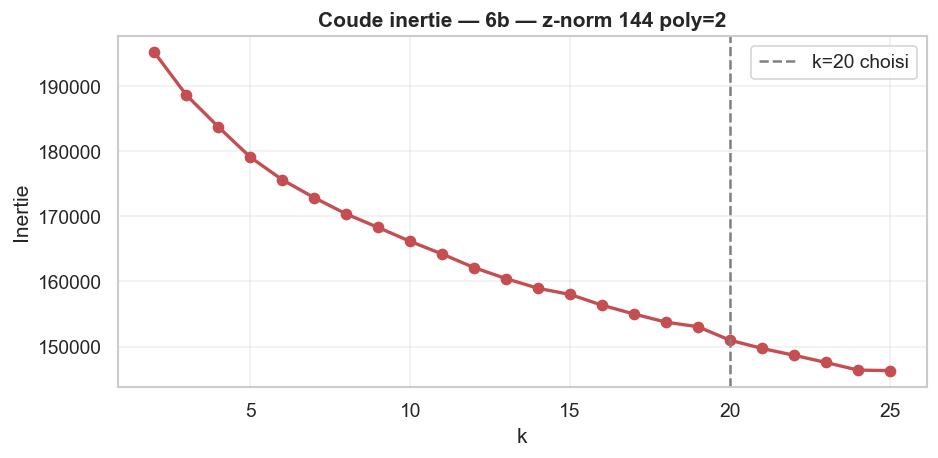

In [ ]:
plot_elbow(X_deriv, k_range=range(2, 26), n_init=10,
           title='6b — z-norm 144 poly=2', mark_k=K_DERIV)


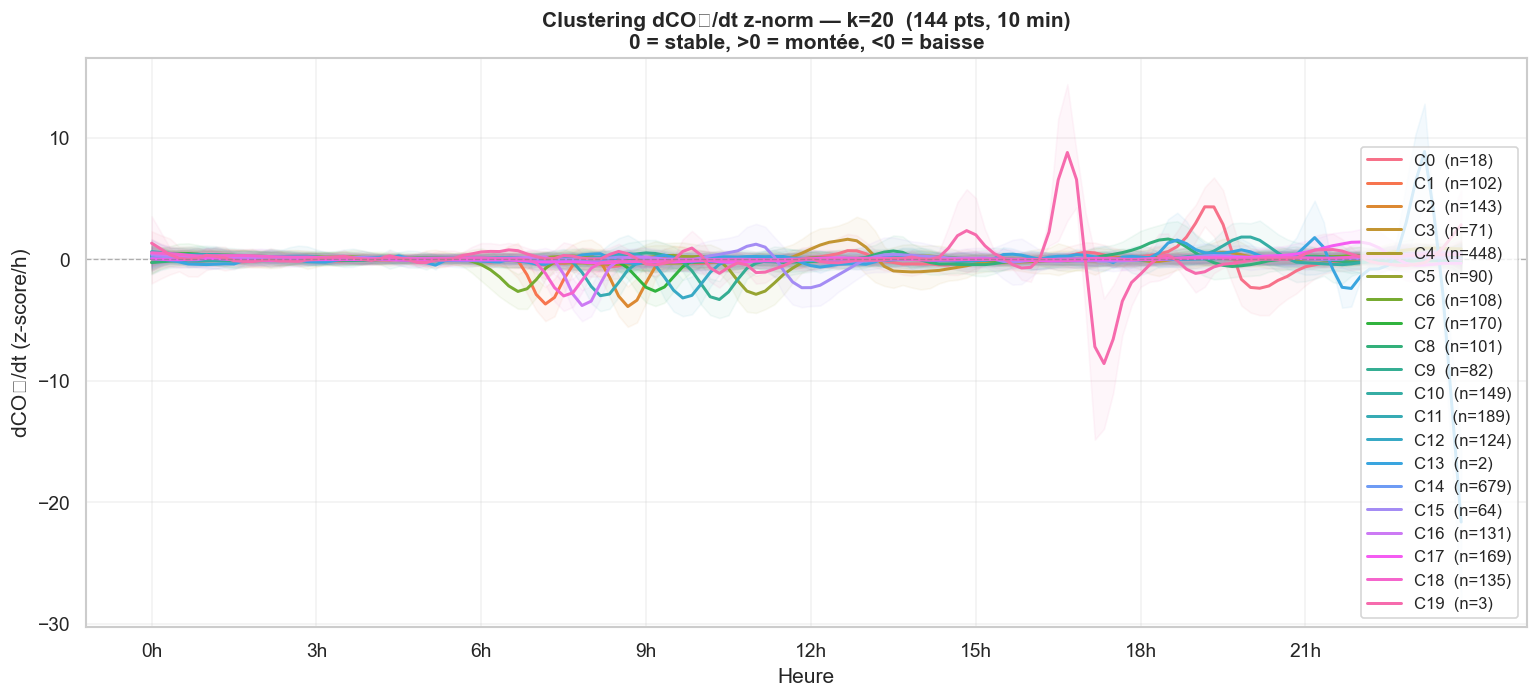

cluster     0    1    2   3    4   5    6    7    8   9    10   11   12  13  \
n journées  18  102  143  71  448  90  108  170  101  82  149  189  124   2   

cluster      14  15   16   17   18  19  
n journées  679  64  131  169  135   3  


In [ ]:
K_DERIV  = 20
deriv_prof['daytype_d'] = KMeans(n_clusters=K_DERIV, random_state=42, n_init=50).fit_predict(X_deriv)

plot_cluster_profiles(deriv_prof, 'daytype_d', np.arange(144) * 10 / 60,
                      'dCO\u2082/dt (z-score/h)',
                      f'Clustering dCO\u2082/dt z-norm \u2014 k={K_DERIV}  (144 pts, 10 min)\n0 = stable, >0 = mont\u00e9e, <0 = baisse')


## 6c. Clustering journées & dérivée dCO₂/dt (sans z-normalisation)



Journées (identiques à 6b) : 2,978
Plage : [-10171.8, 8585.4] ppm/h


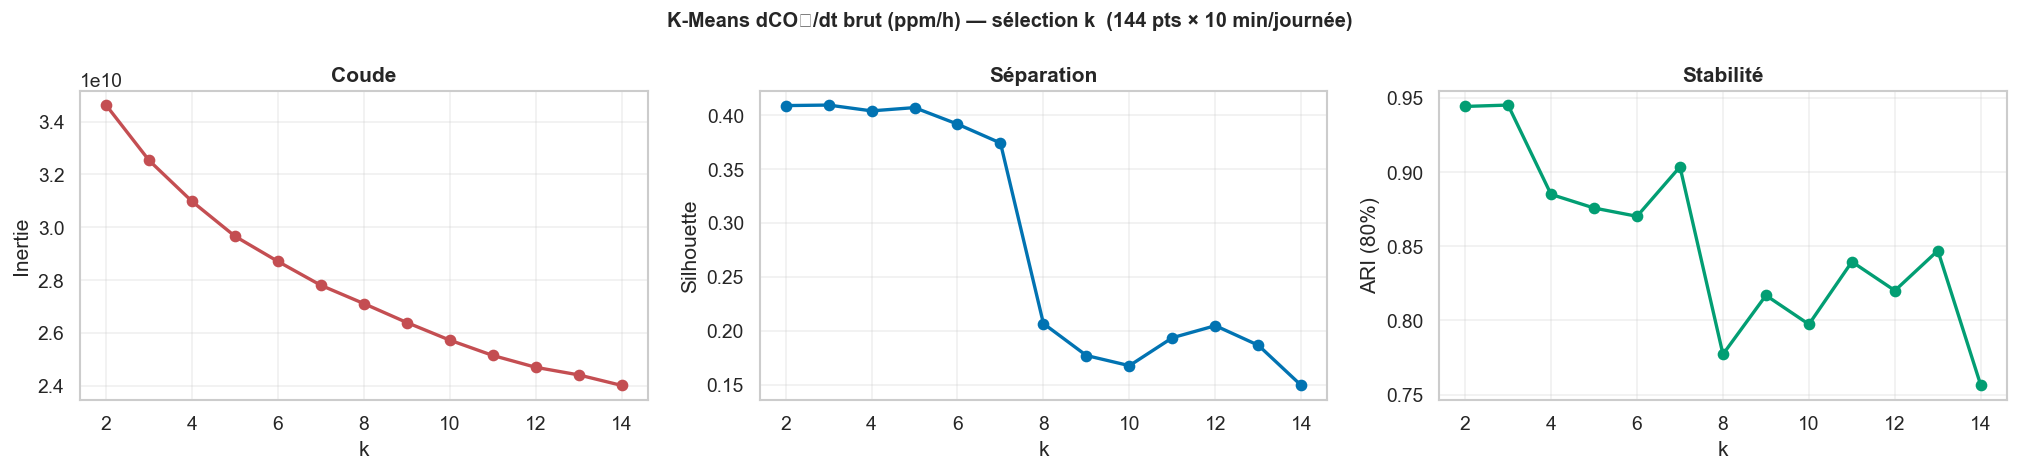

Silhouette max : k=3


In [ ]:
slot_piv_r = (co2_j.groupby(['CODELIEU', 'DATE', 'slot'])['VALEUR']
               .mean().unstack('slot').sort_index(axis=1)
               .loc[slot_piv.index])   # meme jours que 6b, pas de dropna independant
print(f'Journées (identiques à 6b) : {len(slot_piv_r):,}')

deriv_sr = np.apply_along_axis(
    lambda x: savgol_filter(x, WINDOW_10, POLY_10, deriv=1, delta=DELTA_10),
    1, slot_piv_r.values)

deriv_prof_r = pd.DataFrame(deriv_sr, index=slot_piv_r.index, columns=range(144))
X_deriv_r    = deriv_prof_r.values
print(f'Plage : [{X_deriv_r.min():.1f}, {X_deriv_r.max():.1f}] ppm/h')

kmeans_ksel(X_deriv_r, list(range(2, 15)), rng_seed=3,
            suptitle='K-Means dCO₂/dt brut (ppm/h) — sélection k  (144 pts × 10 min/journée)');


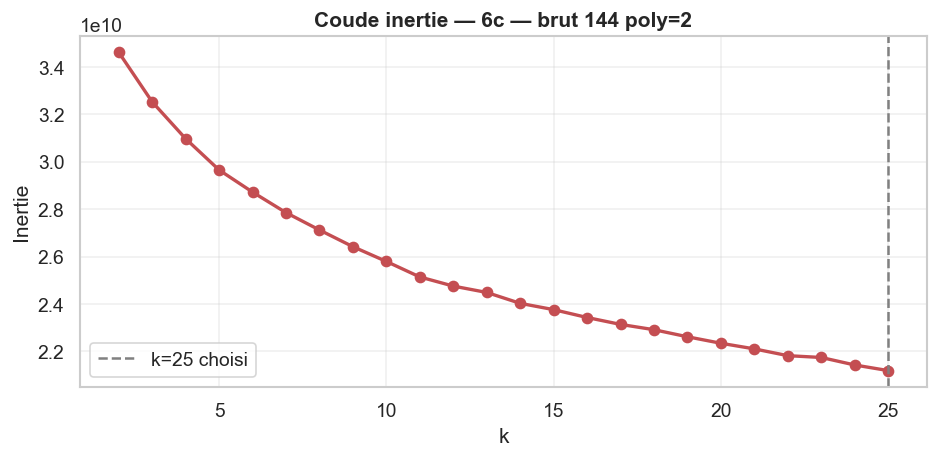

In [ ]:
plot_elbow(X_deriv_r, k_range=range(2, 26), n_init=10,
           title='6c — brut 144 poly=2', mark_k=K_DERIV_R)


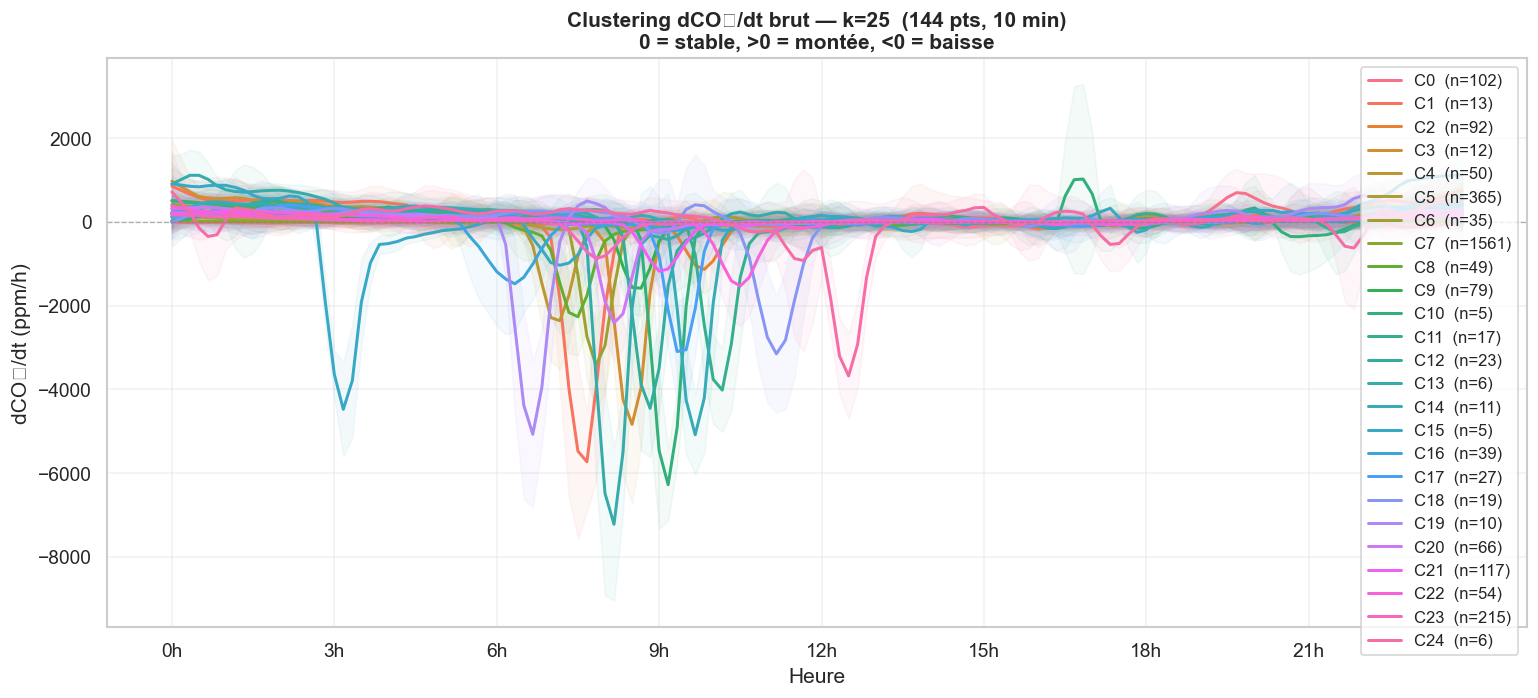

cluster      0   1   2   3   4    5   6     7   8   9   10  11  12  13  14  \
n journées  102  13  92  12  50  365  35  1561  49  79   5  17  23   6  11   

cluster     15  16  17  18  19  20   21  22   23  24  
n journées   5  39  27  19  10  66  117  54  215   6  


In [ ]:
K_DERIV_R = 25
deriv_prof_r['daytype_dr'] = KMeans(n_clusters=K_DERIV_R, random_state=42, n_init=50).fit_predict(X_deriv_r)

plot_cluster_profiles(deriv_prof_r, 'daytype_dr', np.arange(144) * 10 / 60,
                      'dCO\u2082/dt (ppm/h)',
                      f'Clustering dCO\u2082/dt brut \u2014 k={K_DERIV_R}  (144 pts, 10 min)\n0 = stable, >0 = mont\u00e9e, <0 = baisse')


## 6d. Clustering — dérivée z-norm, polynôme deg. 1 (144 pts)

Mêmes données z-normalisées que 6b, mais lissage Savitzky-Golay **poly=1** (régression linéaire locale).
Filtre plus agressif : dérivée constante sur chaque fenêtre → profil plus lissé.


In [ ]:
POLY_1 = 1  
WINDOW_10 = 13; 

deriv_s1 = np.apply_along_axis(
    lambda x: savgol_filter(x, WINDOW_10, POLY_1, deriv=1, delta=DELTA_10),
    1, slot_piv.values)

deriv_prof_1 = pd.DataFrame(deriv_s1, index=slot_piv.index, columns=range(144))
X_deriv_1    = deriv_prof_1.values
print(f'Plage : [{X_deriv_1.min():.3f}, {X_deriv_1.max():.3f}] z-score/h')



Plage : [-5.881, 5.317] z-score/h


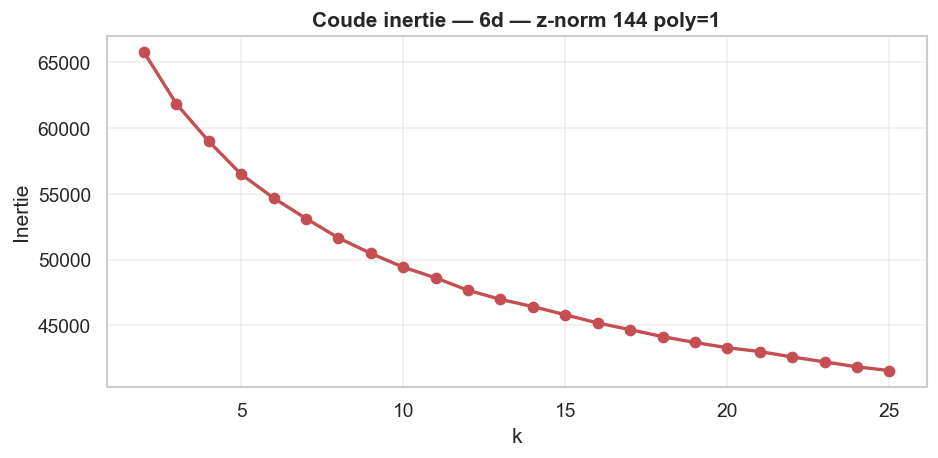

In [ ]:
plot_elbow(X_deriv_1, k_range=range(2, 26), n_init=10,
           title='6d — z-norm 144 poly=1')


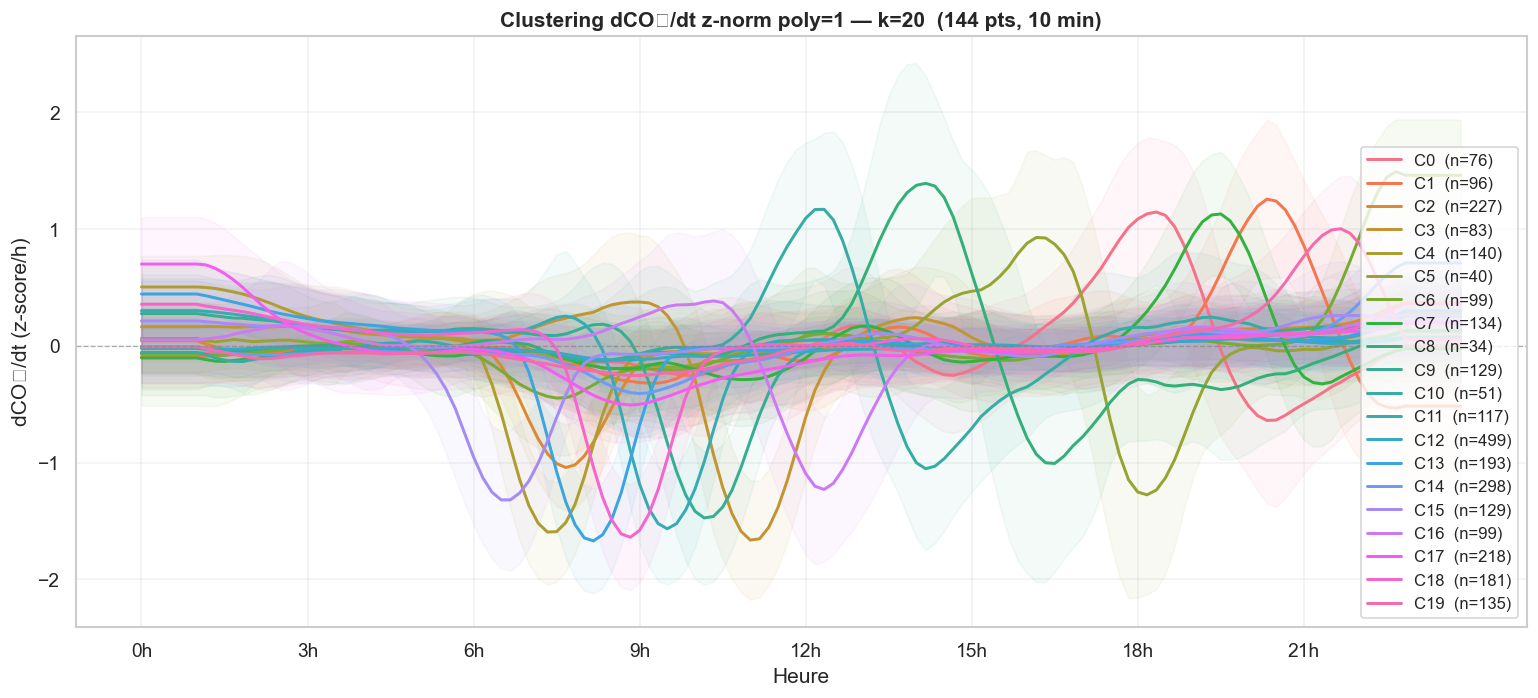

cluster     0   1    2   3    4   5   6    7   8    9   10   11   12   13  \
n journées  76  96  227  83  140  40  99  134  34  129  51  117  499  193   

cluster      14   15  16   17   18   19  
n journées  298  129  99  218  181  135  


In [ ]:
K_DERIV_1 = 20  

deriv_prof_1['daytype_d1'] = KMeans(
    n_clusters=K_DERIV_1, init = 'k-means++',n_init=300
).fit_predict(X_deriv_1)

plot_cluster_profiles(
    deriv_prof_1, 'daytype_d1', np.arange(144) * 10 / 60,
    'dCO₂/dt (z-score/h)',
    f'Clustering dCO₂/dt z-norm poly=1 — k={K_DERIV_1}  (144 pts, 10 min)'
)


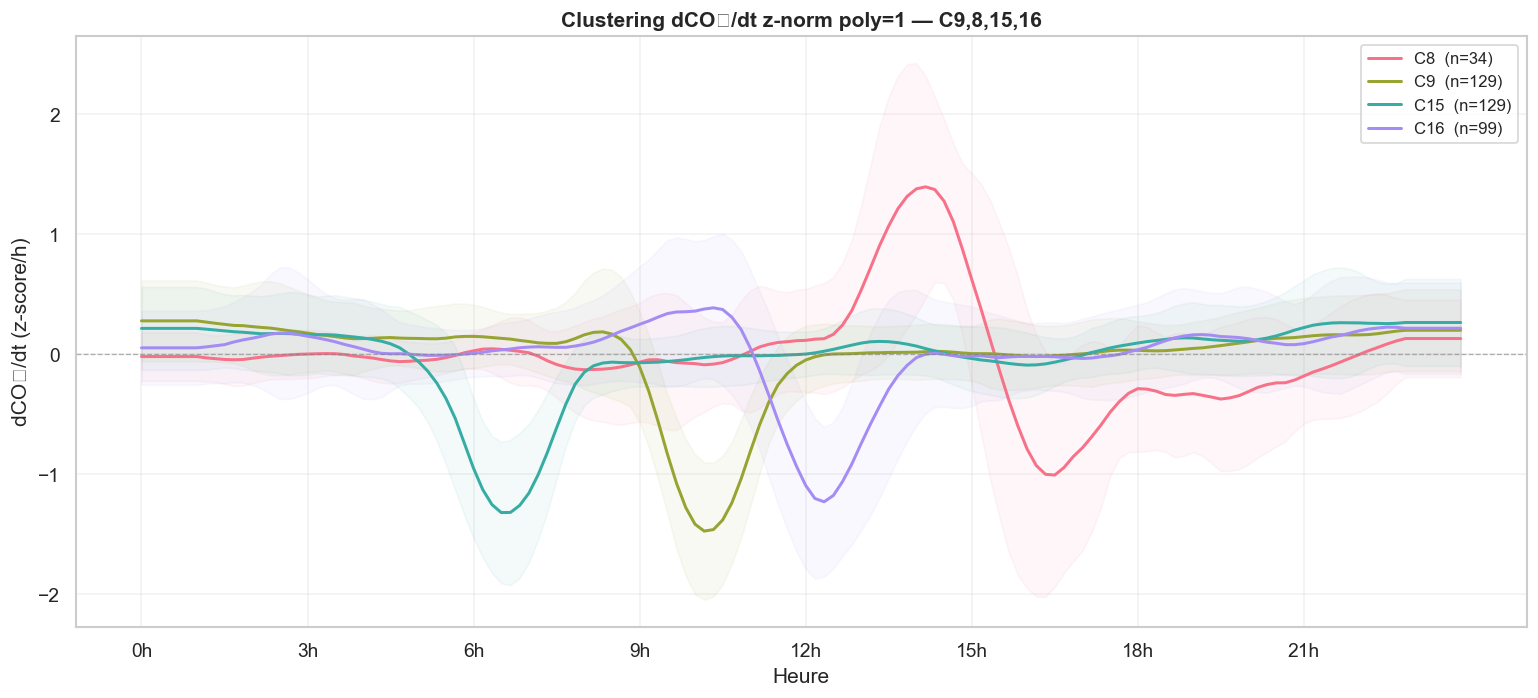

cluster     8    9    15  16
n journées  34  129  129  99


In [ ]:

CLUSTERS_ONLY = [9,8,15,16]

sub_multi = deriv_prof_1[deriv_prof_1['daytype_d1'].isin(CLUSTERS_ONLY)]
plot_cluster_profiles(
    sub_multi, 'daytype_d1', np.arange(144) * 10 / 60,
    'dCO₂/dt (z-score/h)',
    f'Clustering dCO₂/dt z-norm poly=1 — C{",".join(map(str, CLUSTERS_ONLY))}'
)

 129 journees


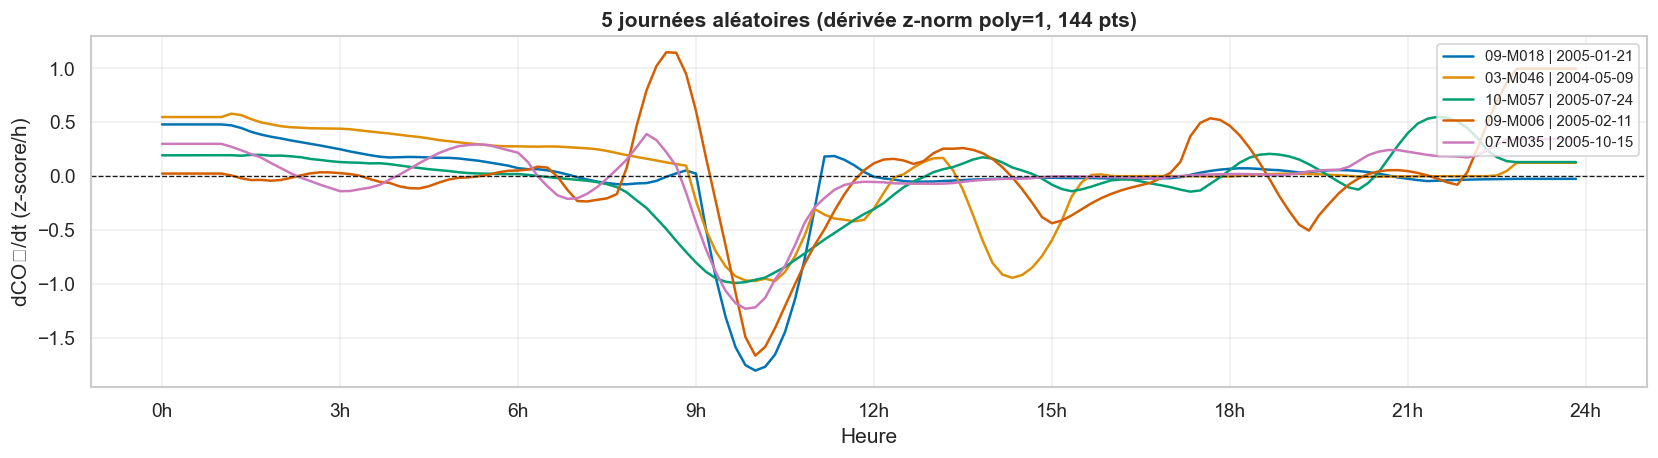

In [ ]:

t144 = np.arange(144) * 10 / 60

idx_c19 = deriv_prof_1[deriv_prof_1['daytype_d1'] == 9].index

print(f' {len(idx_c19)} journees')
rng_c19 = np.random.RandomState(40)
chosen_c19 = idx_c19[rng_c19.choice(len(idx_c19), min(5, len(idx_c19)), replace=False)]

fig, ax = plt.subplots(figsize=(14, 4))
for logement, date in chosen_c19:
    vals = deriv_prof_1.loc[(logement, date), list(range(144))].values
    ax.plot(t144, vals, lw=1.5, label=f'{logement} | {str(date)[:10]}')

ax.axhline(0, color='k', lw=0.8, ls='--')
ax.set_xticks(range(0, 25, 3))
ax.set_xticklabels([f'{h}h' for h in range(0, 25, 3)])
ax.set_xlabel('Heure'); ax.set_ylabel('dCO₂/dt (z-score/h)')
ax.set_title('5 journées aléatoires (dérivée z-norm poly=1, 144 pts)', fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


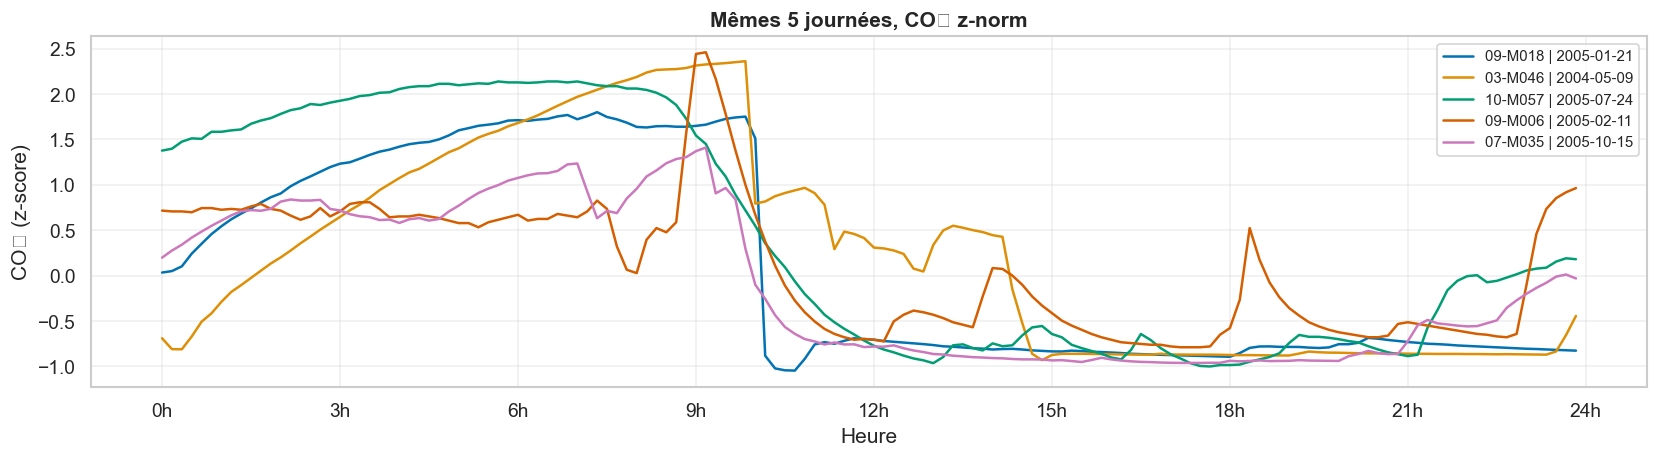

In [ ]:

fig, ax = plt.subplots(figsize=(14, 4))
for logement, date in chosen_c19:
    vals = slot_piv.loc[(logement, date)].values
    ax.plot(t144, vals, lw=1.5, label=f'{logement} | {str(date)[:10]}')

ax.set_xticks(range(0, 25, 3))
ax.set_xticklabels([f'{h}h' for h in range(0, 25, 3)])
ax.set_xlabel('Heure'); ax.set_ylabel('CO₂ (z-score)')
ax.set_title('Mêmes 5 journées, CO₂ z-norm', fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 6e. Clustering — dérivée brut ppm, polynôme deg. 1 (144 pts)

Mêmes données CO₂ brut (ppm) que 6c, mais lissage Savitzky-Golay **poly=1**.


In [ ]:

deriv_sr1 = np.apply_along_axis(
    lambda x: savgol_filter(x, WINDOW_10, POLY_1, deriv=1, delta=DELTA_10),
    1, slot_piv_r.values)

deriv_prof_r1 = pd.DataFrame(deriv_sr1, index=slot_piv_r.index, columns=range(144))
X_deriv_r1    = deriv_prof_r1.values
print(f'Plage : [{X_deriv_r1.min():.1f}, {X_deriv_r1.max():.1f}] ppm/h')



Plage : [-3832.9, 3494.2] ppm/h


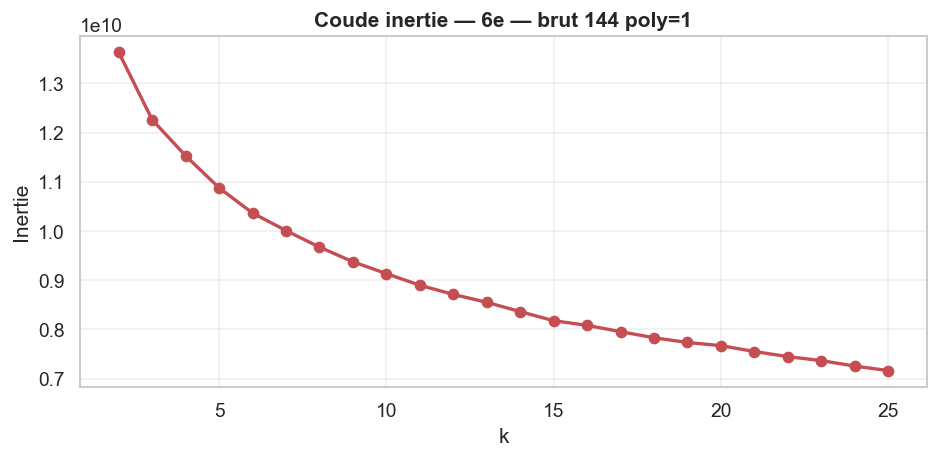

In [ ]:
plot_elbow(X_deriv_r1, k_range=range(2, 26), n_init=10,
           title='6e — brut 144 poly=1')


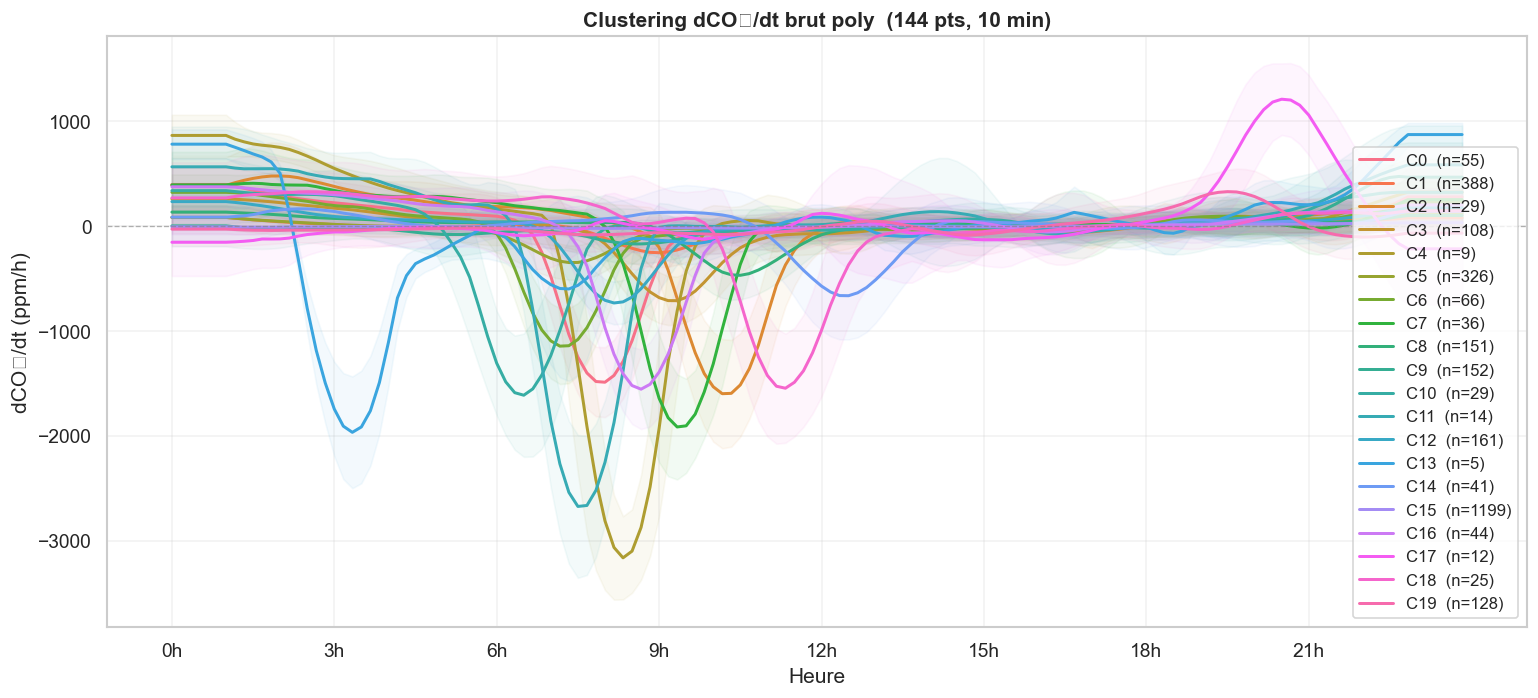

cluster     0    1   2    3   4    5   6   7    8    9   10  11   12  13  14  \
n journées  55  388  29  108   9  326  66  36  151  152  29  14  161   5  41   

cluster       15  16  17  18   19  
n journées  1199  44  12  25  128  


In [ ]:
K_DERIV_R1 = 20  
deriv_prof_r1['daytype_dr1'] = KMeans(
    n_clusters=K_DERIV_R1,init = 'k-means++',n_init=300
).fit_predict(X_deriv_r1)

plot_cluster_profiles(
    deriv_prof_r1, 'daytype_dr1', np.arange(144) * 10 / 60,
    'dCO₂/dt (ppm/h)',
    f'Clustering dCO₂/dt brut poly  (144 pts, 10 min)'
)


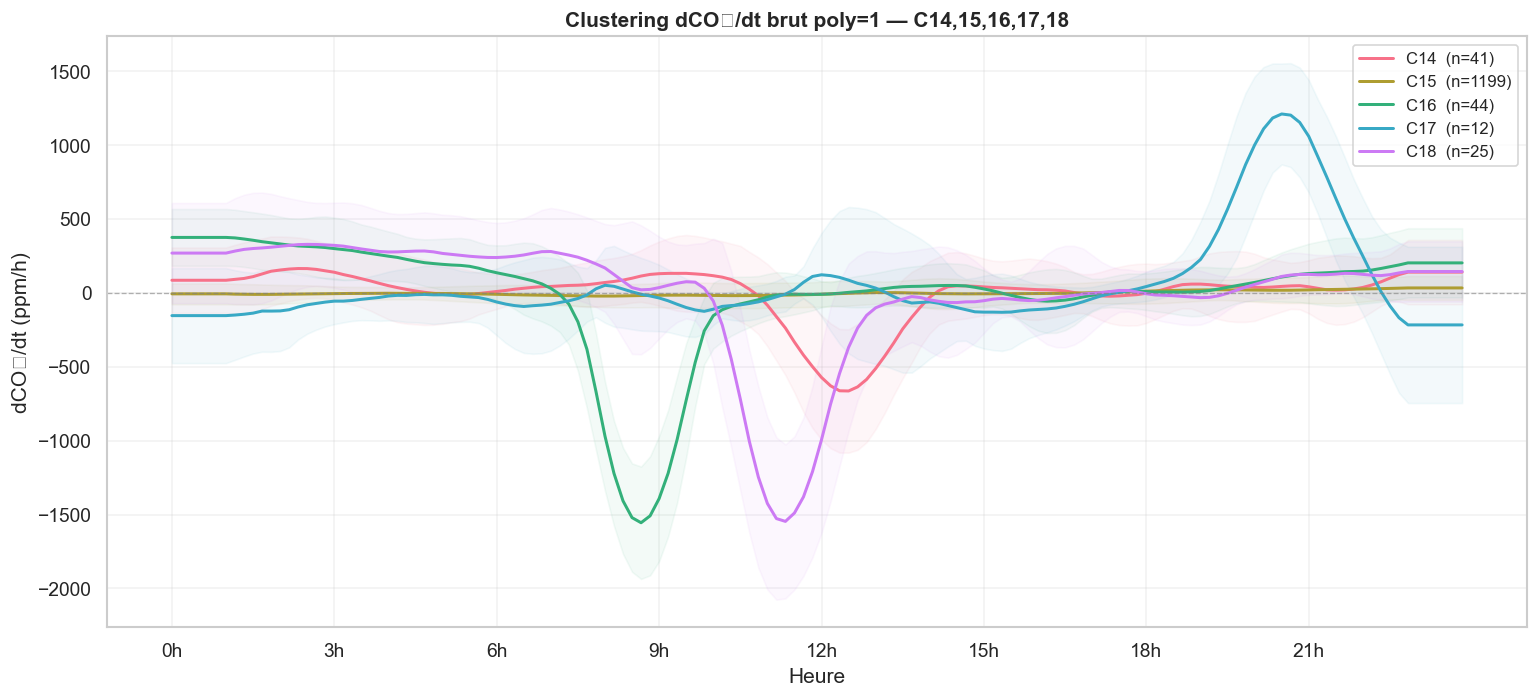

cluster     14    15  16  17  18
n journées  41  1199  44  12  25


In [ ]:

CLUSTERS_ONLY_R1 = [14,15,16,17,18]

sub_multi_r1 = deriv_prof_r1[deriv_prof_r1['daytype_dr1'].isin(CLUSTERS_ONLY_R1)]
plot_cluster_profiles(
    sub_multi_r1, 'daytype_dr1', np.arange(144) * 10 / 60,
    'dCO₂/dt (ppm/h)',
    f'Clustering dCO₂/dt brut poly=1 — C{",".join(map(str, CLUSTERS_ONLY_R1))}'
)


C16 : 44 journees


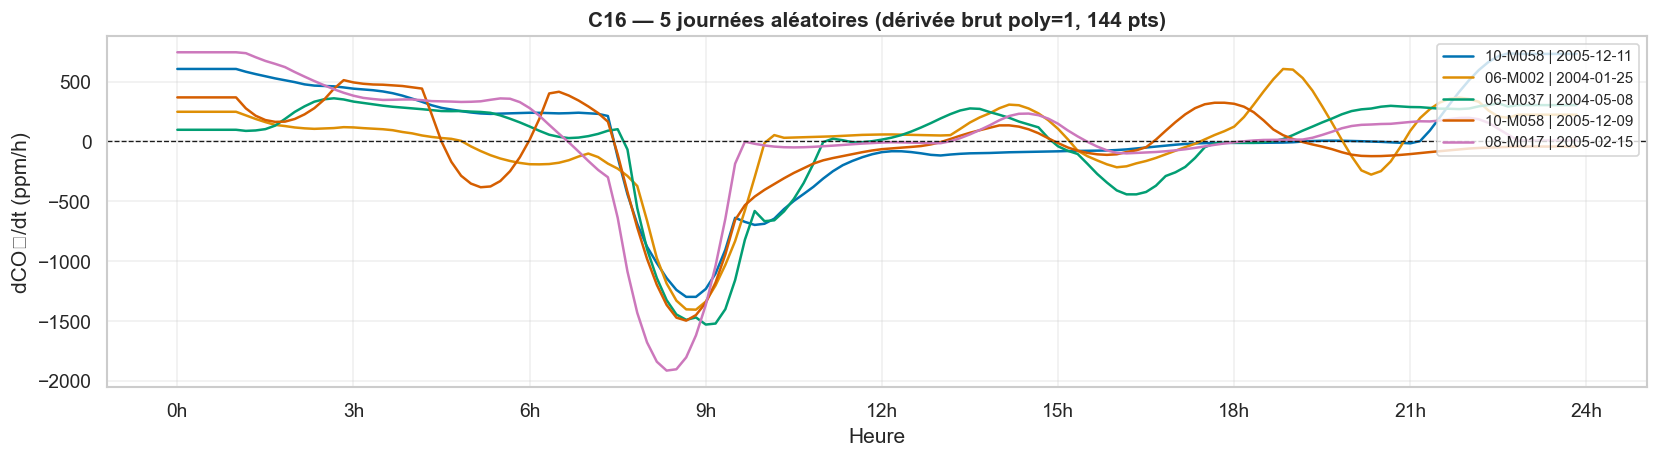

In [ ]:

CLUSTER_VIS = 16  

t144 = np.arange(144) * 10 / 60
idx_cr1 = deriv_prof_r1[deriv_prof_r1['daytype_dr1'] == CLUSTER_VIS].index
print(f'C{CLUSTER_VIS} : {len(idx_cr1)} journees')

rng_cr1 = np.random.RandomState(42)
chosen_cr1 = idx_cr1[rng_cr1.choice(len(idx_cr1), min(5, len(idx_cr1)), replace=False)]

fig, ax = plt.subplots(figsize=(14, 4))
for logement, date in chosen_cr1:
    vals = deriv_prof_r1.loc[(logement, date), list(range(144))].values
    ax.plot(t144, vals, lw=1.5, label=f'{logement} | {str(date)[:10]}')

ax.axhline(0, color='k', lw=0.8, ls='--')
ax.set_xticks(range(0, 25, 3))
ax.set_xticklabels([f'{h}h' for h in range(0, 25, 3)])
ax.set_xlabel('Heure'); ax.set_ylabel('dCO₂/dt (ppm/h)')
ax.set_title(f'C{CLUSTER_VIS} — 5 journées aléatoires (dérivée brut poly=1, 144 pts)', fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


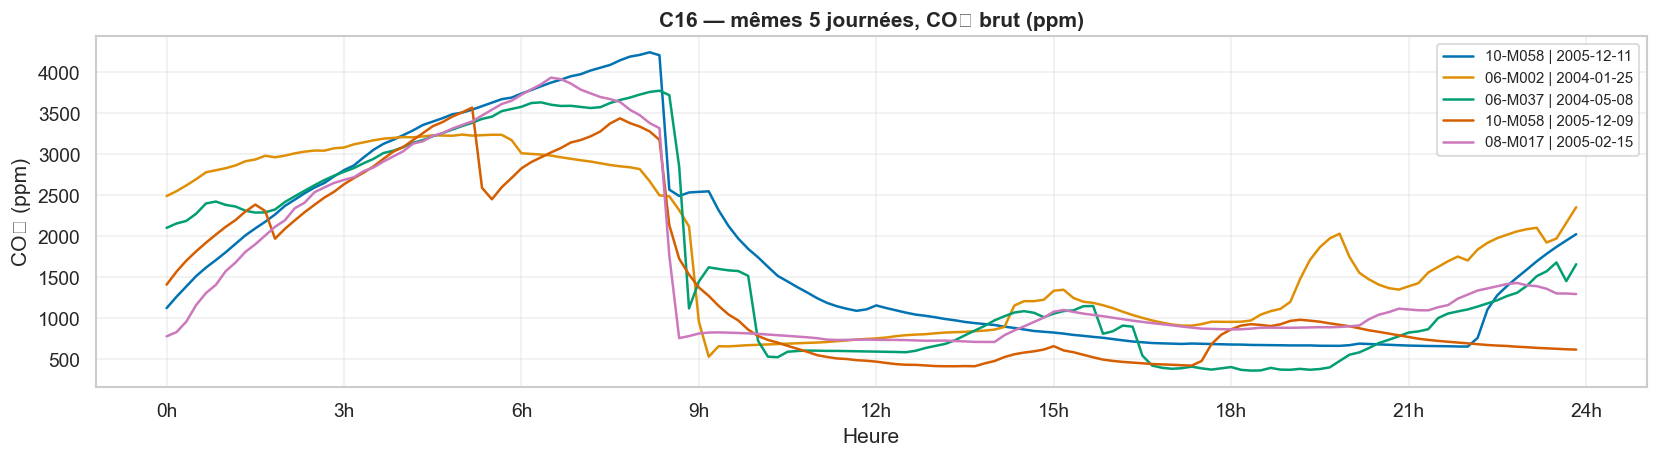

In [ ]:
# Donnees brutes CO2 (ppm) des memes journees que le plot precedent
fig, ax = plt.subplots(figsize=(14, 4))
for logement, date in chosen_cr1:
    vals = slot_piv_r.loc[(logement, date)].values
    ax.plot(t144, vals, lw=1.5, label=f'{logement} | {str(date)[:10]}')

ax.set_xticks(range(0, 25, 3))
ax.set_xticklabels([f'{h}h' for h in range(0, 25, 3)])
ax.set_xlabel('Heure'); ax.set_ylabel('CO₂ (ppm)')
ax.set_title(f'C{CLUSTER_VIS} — mêmes 5 journées, CO₂ brut (ppm)', fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
